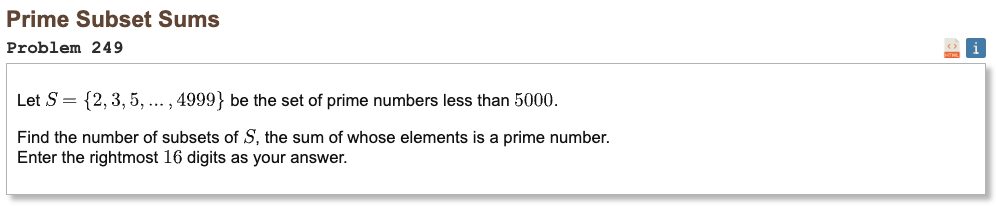

## Initial approach

* list all primes below 5000 and compute the maximum possible subset sum
* use numpy so the subset sum counting step runs fast in vectorized form
* do a dynamic programming array dp where dp[x] means how many subsets sum to x (kept modulo 10^16)
* for each prime p in the set, update dp so every old sum also creates a new sum plus p
* build a prime mask up to the maximum sum so you can quickly pick which sums are prime
* add dp[x] over all prime x, then take modulo 10^16 and print it

In [1]:
from math import isqrt
import numpy as np

MOD = 10**16

def sieve(n):
    is_p = bytearray(b"\x01") * (n + 1)
    if n >= 0:
        is_p[0] = 0
    if n >= 1:
        is_p[1] = 0
    for i in range(2, isqrt(n) + 1):
        if is_p[i]:
            step = i
            start = i * i
            is_p[start:n + 1:step] = b"\x00" * (((n - start) // step) + 1)
    primes = [i for i in range(2, n + 1) if is_p[i]]
    return primes, is_p

def solve():
    primes_5000, _ = sieve(4999)
    total = sum(primes_5000)

    dp = np.zeros(total + 1, dtype=object)
    dp[0] = 1

    for p in primes_5000:
        dp[p:] = (dp[p:] + dp[:-p]) % MOD

    _, is_prime_sum = sieve(total)
    mask = np.frombuffer(is_prime_sum, dtype=np.uint8).astype(bool)

    result = sum(dp[i] for i in range(len(dp)) if mask[i]) % MOD
    print("Result:", result)

solve()

Result: 9275262564250418
